In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("../data/spam.csv",encoding="latin-1")

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3040,ham,Aight what time you want me to come up?,NaN,NaN,NaN
3065,spam,Get a brand new mobile phone by being an agent...,NaN,NaN,NaN
1118,ham,I'm going 4 lunch now wif my family then aft d...,NaN,NaN,NaN
4336,ham,on a Tuesday night r u 4 real,NaN,NaN,NaN
3948,ham,HMM yeah if your not too grooved out! And im l...,NaN,NaN,NaN


In [4]:
df.shape


(5572, 5)

In [5]:
#1.data cleaning
#2. eda
#3. text preprocessing
#4. model building
#5. evaluation 
#6. improvement
#7. website
#8. deploy

# data cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# drop last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
df.sample(5)

,v1,v2
754,ham,Realy sorry-i don't recognise this number and ...
197,ham,is your hamster dead? Hey so tmr i meet you at...
3957,ham,So i could kiss and feel you next to me...
540,spam,from www.Applausestore.com MonthlySubscription...
126,ham,"Just so that you know,yetunde hasn't sent mone..."


In [9]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3988,ham,Ok lor. Anyway i thk we cant get tickets now c...
2574,spam,Your next amazing xxx PICSFREE1 video will be ...
4029,ham,"Cool, I'll text you in a few"
4219,ham,U free on sat rite? U wan 2 watch infernal aff...
3390,ham,"I'm in a meeting, call me later at"


In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder= LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df = df.drop_duplicates(keep='first')

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(5169, 2)

#2.EDA

In [18]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [19]:
import matplotlib.pyplot as plt

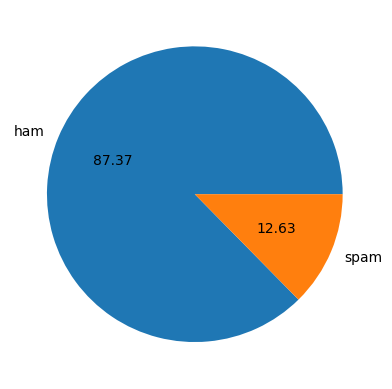

In [20]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Data is imbalanced


In [21]:
import nltk

In [22]:
from nltk.tokenize import sent_tokenize
nltk.download('punkt', force=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khushi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [23]:
df['num_characters']=df['text'].apply(len)

In [24]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
df['num_words'] = df['text'].apply(lambda x: len(str(x).split()))


In [26]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [27]:
import re

df["new_sentence"] = df["text"].apply(
    lambda x: len(re.findall(r'[.!?]+', str(x)))
)


In [28]:
df.head()

,target,text,num_characters,num_words,new_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


In [29]:
df[['num_characters','num_words','new_sentence']].describe()

,num_characters,num_words,new_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,1.846779
std,58.236293,11.068488,1.745441
min,2.000000,1.000000,0.000000
25%,36.000000,7.000000,1.000000
50%,60.000000,12.000000,2.000000
75%,117.000000,22.000000,3.000000
max,910.000000,171.000000,39.000000


In [30]:
df[df['target']==0][['num_characters','num_words','new_sentence']].describe()

,num_characters,num_words,new_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,14.134632,1.692648
std,56.358207,11.116240,1.681598
min,2.000000,1.000000,0.000000
25%,34.000000,7.000000,1.000000
50%,52.000000,11.000000,1.000000
75%,90.000000,18.000000,2.000000
max,910.000000,171.000000,39.000000


In [31]:
df[df['target']==1][['num_characters','num_words','new_sentence']].describe()

,num_characters,num_words,new_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,23.681470,2.912711
std,30.137753,5.967672,1.806610
min,13.000000,2.000000,0.000000
25%,132.000000,22.000000,2.000000
50%,149.000000,25.000000,3.000000
75%,157.000000,28.000000,4.000000
max,224.000000,35.000000,9.000000


In [32]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

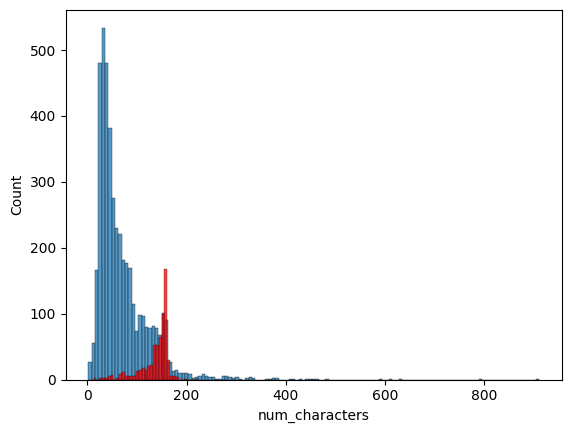

In [33]:
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

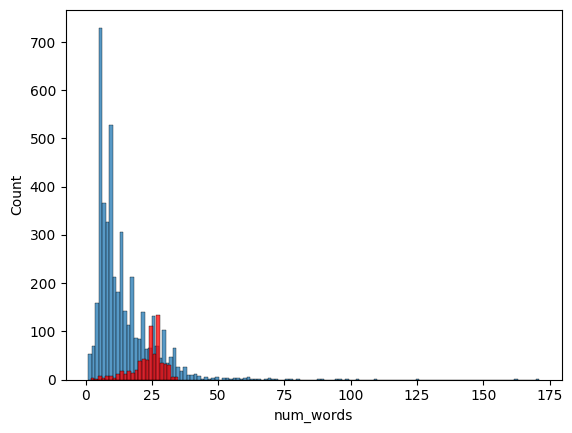

In [34]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

In [35]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khushi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\khushi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\khushi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('dancing')

'danc'

In [37]:
import string
import nltk
from nltk.corpus import stopwords

def transform_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Tokenization (Separates words and punctuation)
    words = nltk.word_tokenize(text)
    
    y = []
    # 3. Filter the words
    for i in words:
        # Check: Is it alphanumeric? AND not a stopword? AND not punctuation?
        # Note: string.punctuation is the correct spelling
        if i.isalnum(): 
            if i not in stopwords.words('english') and i not in string.punctuation:
                y.append(i)
    
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

# Test it
print(transform_text("Hi how are you? This is a %^ test learning !"))

hi test learn


In [38]:
transform_text('Hi how are %% You')

'hi'

In [39]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [40]:
df["transformed_text"]=df["text"].apply(transform_text)

In [41]:
df.head()

,target,text,num_characters,num_words,new_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah think goe usf live around though


In [42]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [43]:
spam_wc = wc.generate(df[df['target']==1]["transformed_text"].str.cat(sep=" "))

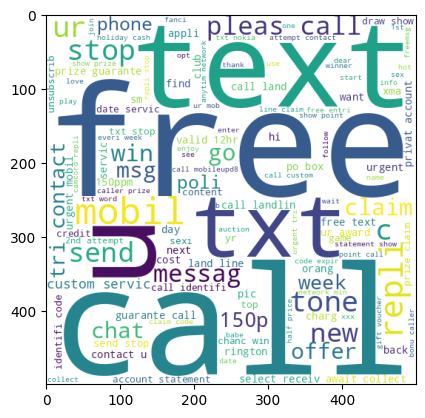

In [44]:
plt.imshow(spam_wc)

In [45]:
ham_wc = wc.generate(df[df['target']==0]["transformed_text"].str.cat(sep=" "))

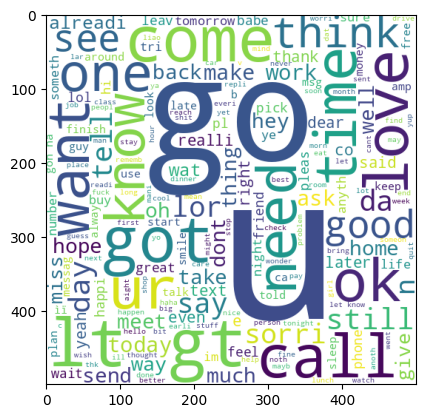

In [46]:
plt.imshow(ham_wc)

In [47]:
df.head()

,target,text,num_characters,num_words,new_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah think goe usf live around though


In [48]:
type(df)

pandas.core.frame.DataFrame

In [49]:
print(type(df))
print(df.columns)
print(df.head(1))



<class 'pandas.core.frame.DataFrame'>
Index(['target', 'text', 'num_characters', 'num_words', 'new_sentence',
       'transformed_text'],
      dtype='object')
   target                                               text  num_characters  \
0       0  Go until jurong point, crazy.. Available only ...             111   

   num_words  new_sentence                                   transformed_text  
0         20             3  go jurong point crazi avail bugi n great world...  


In [50]:
df = pd.read_csv("../data/spam.csv", encoding='latin-1')

df = df[['v1','v2']]
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

df['transformed_text'] = df['text'].apply(transform_text)


In [51]:
spam_corpus = []

for msg in df[df['target'] == 1]['transformed_text']:
    for word in msg.split():
        spam_corpus.append(word)


In [52]:
len(spam_corpus)

11490

In [53]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [54]:
len(ham_corpus)

38221

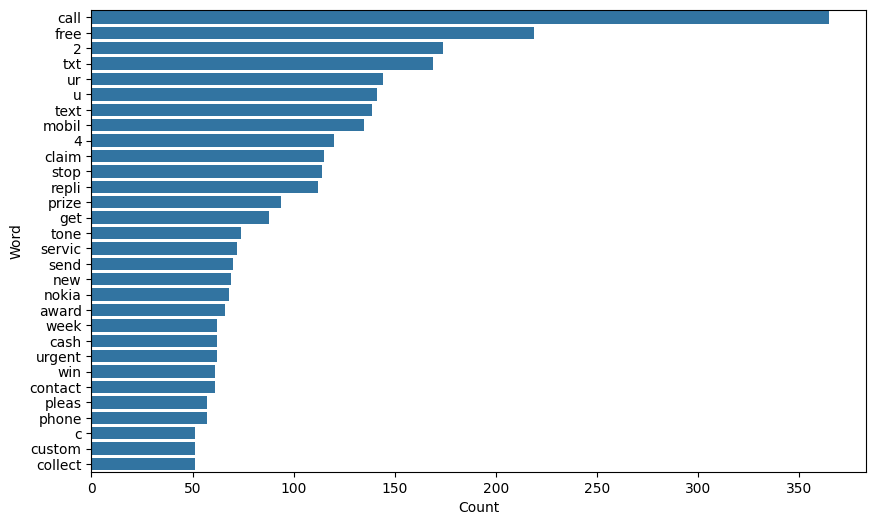

In [55]:
from collections import Counter

# Get top 30 words
top_words = Counter(spam_corpus).most_common(30)

# Convert to DataFrame
df = pd.DataFrame(top_words, columns=["Word", "Count"])

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Count", y="Word", data=df)
plt.show()


# Model building

In [56]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [57]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

ps = PorterStemmer()

def transformed_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(ps.stem(i))
    
    return " ".join(y)

In [59]:
df['transformed_text'] = df['text'].apply(transformed_text)


In [58]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/spam.csv", encoding='latin-1')

# Keep only required columns
df = df[['v1','v2']]

# Rename columns
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)

# Encode target
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

# Create transformed_text
df['transformed_text'] = df['text'].apply(transformed_text)


In [60]:
X = cv.fit_transform(df['transformed_text'])


In [61]:
X.shape

(5572, 6708)

In [62]:
y = df['target'].values

In [63]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [67]:
bnb = BernoulliNB()


In [68]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

print("Model trained successfully")
print(hasattr(bnb, "classes_"))   # Should print True


Model trained successfully
True


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [70]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
bnb = BernoulliNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [71]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': bnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [72]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return clf, accuracy, precision


In [73]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(SVC(gamma=1.0, kernel='sigmoid'), 0.9291479820627803, 0.8211382113821138)

In [74]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision


In [75]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(
        clf, X_train, y_train, X_test, y_test
    )

    print("For", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


For SVC
Accuracy - 0.9291479820627803
Precision - 0.8211382113821138
For KN
Accuracy - 0.9067264573991032
Precision - 1.0
For NB
Accuracy - 0.9695067264573991
Precision - 0.9920634920634921
For DT
Accuracy - 0.905829596412556
Precision - 0.9206349206349206


C:\Users\khushi\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\khushi\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For LR
Accuracy - 0.9695067264573991
Precision - 0.984375
For RF
Accuracy - 0.9605381165919282
Precision - 0.9913793103448276
For AdaBoost
Accuracy - 0.9121076233183857
Precision - 0.8947368421052632
For BgC
Accuracy - 0.9650224215246637
Precision - 0.976
For ETC
Accuracy - 0.967713004484305
Precision - 1.0
For GBDT
Accuracy - 0.9381165919282511
Precision - 0.9587628865979382
For xgb
Accuracy - 0.9659192825112107
Precision - 0.9838709677419355


In [76]:
import pandas as pd

performance_df = pd.DataFrame({
    "Algorithm": clfs.keys(),
    "Accuracy": accuracy_scores,
    "Precision": precision_scores
})

performance_df


,Algorithm,Accuracy,Precision
0,SVC,0.929148,0.821138
1,KN,0.906726,1.000000
2,NB,0.969507,0.992063
3,DT,0.905830,0.920635
4,LR,0.969507,0.984375
5,RF,0.960538,0.991379
6,AdaBoost,0.912108,0.894737
7,BgC,0.965022,0.976000
8,ETC,0.967713,1.000000
9,GBDT,0.938117,0.958763


In [77]:
performance_df = performance_df.sort_values(by="Precision", ascending=False)

performance_df


,Algorithm,Accuracy,Precision
1,KN,0.906726,1.000000
8,ETC,0.967713,1.000000
2,NB,0.969507,0.992063
5,RF,0.960538,0.991379
4,LR,0.969507,0.984375
10,xgb,0.965919,0.983871
7,BgC,0.965022,0.976000
9,GBDT,0.938117,0.958763
3,DT,0.905830,0.920635
6,AdaBoost,0.912108,0.894737


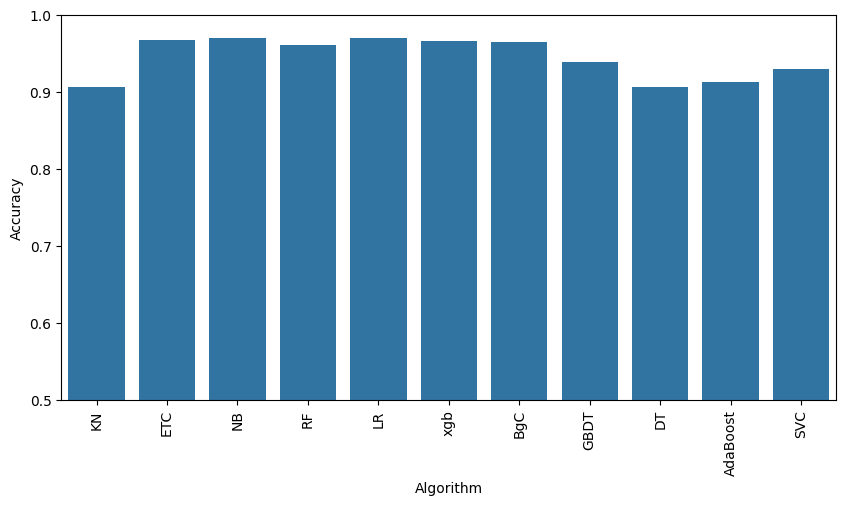

In [78]:
plt.figure(figsize=(10,5))
sns.barplot(x='Algorithm', y='Accuracy', data=performance_df)
plt.xticks(rotation='vertical')
plt.ylim(0.5,1.0)
plt.show()

# model improve

In [79]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [80]:
performance_df.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.906726,1.000000,0.906726,1.000000
1,ETC,0.967713,1.000000,0.967713,1.000000
2,NB,0.969507,0.992063,0.969507,0.992063
3,RF,0.960538,0.991379,0.960538,0.991379
4,LR,0.969507,0.984375,0.969507,0.984375
5,xgb,0.965919,0.983871,0.965919,0.983871
6,BgC,0.965022,0.976000,0.965022,0.976000
7,GBDT,0.938117,0.958763,0.938117,0.958763
8,DT,0.905830,0.920635,0.905830,0.920635
9,AdaBoost,0.912108,0.894737,0.912108,0.894737


In [81]:
# Define models
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
bnb = BernoulliNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

# Voting classifier
voting = VotingClassifier(
    estimators=[('svm', svc), ('nb', bnb), ('et', etc)],
    voting='soft'
)

# Train
voting.fit(X_train, y_train)

# Predict
y_pred = voting.predict(X_test)


In [82]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', bnb), ('et', etc)],voting='soft')

In [83]:
voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [84]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.968609865470852
Precision 1.0


In [85]:

# Applying stacking
estimators=[('svm', svc), ('nb', bnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [86]:
from sklearn.ensemble import StackingClassifier

In [87]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [88]:

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9802690582959641
Precision 0.9415584415584416


In [89]:
import os
import pickle

save_path = r"C:\Users\khushi\OneDrive\Desktop\mlfirstproject\src\notebook"

pickle.dump(cv, open(os.path.join(save_path, "vectorizer.pkl"), "wb"))
pickle.dump(voting, open(os.path.join(save_path, "model.pkl"), "wb"))

print("Voting model saved successfully")


Voting model saved successfully


In [90]:
print(hasattr(cv, "vocabulary_"))


True


In [91]:
import os
print(os.getcwd())


C:\Users\khushi\OneDrive\Desktop\mlfirstproject\src\notebook
